# 03 — Regime-Stratified Evaluation (Section 5.5)

Walk-forward validation prevents look-ahead bias but says nothing about *which market conditions* the test windows covered. A volatility model validated mostly on a calm uptrend tells you little about its behaviour in a drawdown — which is exactly when a risk engine matters most.

This is **not** a regime-switching model (the project's calibration work found that unjustified). It is regime-stratified *reporting*: label each period by market state, then report model skill **per regime**, with the bar set as 'beat the baseline in every regime bucket', not just on average. Aggregate skill can hide a model that is strong in calm markets and useless in volatile ones.

In [3]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")

In [4]:
# Ensure the project root is on the import path so `src` can be imported.
project_root = Path.cwd().resolve()
for candidate in (project_root, *project_root.parents):
    if (candidate / "src").exists():
        sys.path.insert(0, str(candidate))
        break

from src.forecast_engine.forecasting.gbm_boost import VolatilityModel, TARGET_COLUMN
from src.forecast_engine.features.schema import FEATURE_NAMES
from src.forecast_engine.evaluation.splits import walk_forward_splits
from src.forecast_engine.evaluation.baselines import persistence_volatility_baseline
from src.forecast_engine.data.loader import PROCESSED_FEATURES_PATH, load_processed_features

data = load_processed_features()
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values(["symbol", "date"]).reset_index(drop=True)
feature_cols = [c for c in FEATURE_NAMES if c in data.columns and not data[c].isna().all()]

print(f'Loaded {len(data):,} rows for {data["symbol"].nunique():,} tickers')
print(f"Dates: {data['date'].min().date()} to {data['date'].max().date()}")
print(f'Source: {PROCESSED_FEATURES_PATH}')
data.head()

Loaded 622,731 rows for 502 tickers
Dates: 2021-07-19 to 2026-07-17
Source: D:\StockForecastRisk\data\processed\sp500_features.parquet


,date,symbol,security,gics_sector,gics_sub_industry,adj_close,close,high,low,open,...,treasury_2y,fed_funds_rate,vix_term_ratio,yield_curve_slope,vix_change_5d,hy_credit_spread_change_5d,yield_curve_slope_change_5d,vix_change_20d,hy_credit_spread_change_20d,yield_curve_slope_change_20d
0,2021-07-19,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,142.434052,147.580002,147.970001,146.949997,147.660004,...,0.21,0.1,0.903614,0.98,6.17,NaN,-0.16,6.48,NaN,-0.24
1,2021-07-20,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,144.094101,149.300003,151.250000,147.830002,148.449997,...,0.20,0.1,0.850431,1.03,2.72,NaN,-0.05,3.90,NaN,-0.17
2,2021-07-21,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,143.756302,148.949997,149.910004,147.600006,149.490005,...,0.22,0.1,0.818930,1.08,-0.54,NaN,0.02,2.43,NaN,-0.15
3,2021-07-22,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,145.059174,150.300003,150.500000,148.669998,149.710007,...,0.20,0.1,0.809241,1.07,-0.76,NaN,0.01,2.62,NaN,-0.13
4,2021-07-23,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,146.999084,152.309998,152.410004,150.429993,150.589996,...,0.22,0.1,0.794457,1.08,-1.25,NaN,0.02,2.13,NaN,-0.12


## Label market regimes

A simple, defensible scheme: classify each date by the cross-sectional median realised volatility that day into **calm / normal / volatile** terciles. This is market-wide (a regime is a property of the date, not the ticker) and point-in-time (uses only that day's realised vol, no forward information). Hard-coded crisis windows (2020 crash, 2022 bear) could be added, but data-driven terciles avoid hindsight labelling.

In [5]:
if "realized_vol_20_annualized" in data.columns:
    daily_vol = data.groupby("date")["realized_vol_20_annualized"].median()
else:
    daily_vol = data.groupby("date")[TARGET_COLUMN].median()

low, high = daily_vol.quantile([0.33, 0.66])
def label(v):
    if v <= low: return "calm"
    if v <= high: return "normal"
    return "volatile"
regime_by_date = daily_vol.apply(label)
data["regime"] = data["date"].map(regime_by_date)
print(regime_by_date.value_counts().to_string())

realized_vol_20_annualized
volatile    441
calm        407
normal      407


## Model vs baseline, per regime

Walk-forward as in 08b. On each out-of-sample fold, record the model prediction, the persistence baseline, and the regime label, then compute R² within each regime bucket for both.

In [6]:
PURGE_DAYS = 5
model_data = data.dropna(subset=feature_cols + [TARGET_COLUMN]).reset_index(drop=True)
persist = persistence_volatility_baseline(model_data, window=5)
model_data = model_data.assign(persist=persist.values)

records = []
for fold, (tr, te) in enumerate(walk_forward_splits(model_data, purge_days=PURGE_DAYS), start=1):
    m = VolatilityModel(feature_cols, schema_version="2.2").fit(model_data.loc[tr])
    block = model_data.loc[te, ["regime", TARGET_COLUMN, "persist"]].copy()
    block["pred"] = m.predict(model_data.loc[te])
    records.append(block)
    print(f"fold {fold} done")
oos = pd.concat(records, ignore_index=True).dropna(subset=["persist"])

rows = []
for regime in ["calm", "normal", "volatile"]:
    sub = oos[oos["regime"] == regime]
    if len(sub) < 30:
        continue
    rows.append({
        "regime": regime, "n": len(sub),
        "model_r2": r2_score(sub[TARGET_COLUMN], sub["pred"]),
        "baseline_r2": r2_score(sub[TARGET_COLUMN], sub["persist"]),
    })
by_regime = pd.DataFrame(rows).set_index("regime")
by_regime["model_beats_baseline"] = by_regime["model_r2"] > by_regime["baseline_r2"]
display(by_regime.round(4))

fold 1 done
fold 2 done
fold 3 done
fold 4 done
fold 5 done


,n,model_r2,baseline_r2,model_beats_baseline
regime,,,,
calm,178098,0.2592,-0.3590,True
normal,147072,0.2889,-0.3388,True
volatile,107079,0.2601,-0.3203,True


## ★ Verdict

model beats baseline in EVERY regime: True

ROBUST across regimes -- the model's skill is not an artefact of calm periods.


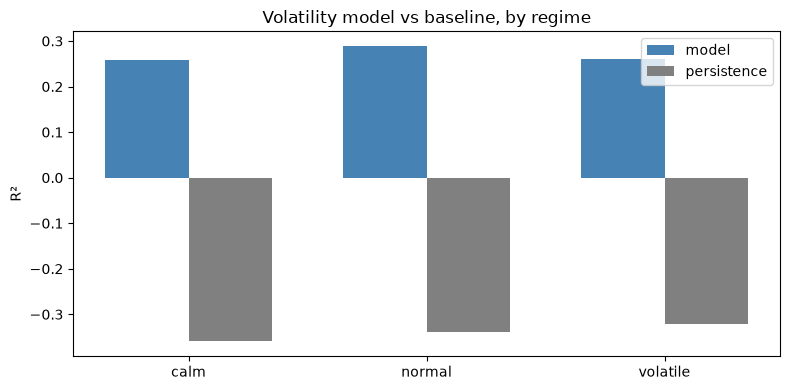


Note: watch small-n regimes -- a volatile bucket with few days gives a noisy R².


In [7]:
all_beat = bool(by_regime["model_beats_baseline"].all())
print(f"model beats baseline in EVERY regime: {all_beat}\n")
if all_beat:
    print("ROBUST across regimes -- the model's skill is not an artefact of calm periods.")
else:
    weak = by_regime[~by_regime['model_beats_baseline']].index.tolist()
    print(f"FAILS in: {weak}. Aggregate skill hides this. Flag lower confidence when")
    print("the live market enters these regimes (feeds back into 5.4 drift monitoring).")

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(by_regime)); w = 0.35
ax.bar(x - w/2, by_regime["model_r2"], w, label="model", color="steelblue")
ax.bar(x + w/2, by_regime["baseline_r2"], w, label="persistence", color="grey")
ax.set_xticks(x); ax.set_xticklabels(by_regime.index); ax.set_ylabel("R²")
ax.set_title("Volatility model vs baseline, by regime"); ax.legend()
plt.tight_layout(); plt.show()

print("\nNote: watch small-n regimes -- a volatile bucket with few days gives a noisy R².")

## Conclusions

**Beats baseline in every regime** — the volatility signal is robust, not a calm-market artefact. The forecast can be trusted across conditions, including the drawdowns the risk engine exists for.

**Fails in some regime** — the model has a blind spot the aggregate R² concealed. The honest response is not necessarily to discard it, but to *flag lower confidence when the live market enters that regime* — which connects directly to the uncertainty band (notebook 01) and to drift monitoring (5.4). Knowing where the model is weak is itself a deliverable.

**Small-sample caution:** rare regimes (deep drawdowns) may have few days, so their R² is noisy. Report the n alongside the metric and resist over-trusting a number from a thin bucket.